In [98]:
import pdblp
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xbbg import blp
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
def get_USD_25D_Call(ccys, tenors, days):
    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=days)).strftime("%Y-%m-%d")
    df_vols = {}
    for ccy in ccys:
        for tenor in tenors:
            ticker_ATM = f"{ccy}V{tenor} BGN Curncy"
            ticker_RR = f"{ccy}25R{tenor} BGN Curncy"
            ticker_BF = f"{ccy}25B{tenor} BGN Curncy"
            data_ATM = blp.bdh(tickers=[ticker_ATM], flds="PX_LAST", start_date=start_date, end_date=end_date)
            data_RR = blp.bdh(tickers=[ticker_RR], flds="PX_LAST", start_date=start_date, end_date=end_date)
            data_BF = blp.bdh(tickers=[ticker_BF], flds="PX_LAST", start_date=start_date, end_date=end_date)
            if data_ATM.empty or data_RR.empty or data_BF.empty:
                print(f"Missing data for {ccy} {tenor}, skipping.")
                continue
            data_ATM.columns = ['ATM']
            data_RR.columns = ['RR']
            data_BF.columns = ['BF']
            df_temp = pd.concat([data_ATM, data_RR, data_BF], axis=1)
            usd_is_base = ccy[:3] == 'USD'
            if usd_is_base:
                df_temp['USD_25dCall'] = df_temp['ATM'] + df_temp['BF'] + df_temp['RR'] / 2
            else:
                df_temp['USD_25dCall'] = df_temp['ATM'] + df_temp['BF'] - df_temp['RR'] / 2
            col_name = f"{ccy}_{tenor}"
            df_vols[col_name] = df_temp[['USD_25dCall']].rename(columns={'USD_25dCall': col_name})
    if df_vols:
        df_all = pd.concat(df_vols.values(), axis=1)
        return round(df_all, 2)
    else:
        print("No data retrieved for any ticker.")
        return None

def get_current_percentiles_by_lookback(
    ccys,
    tenors,
    days_history=365*3,  # needs to be >= max window
    lookbacks=None,
    include_today=True,
    return_current_vols=False):
    if lookbacks is None:
        lookbacks = {
            "3M Percentile": 63,
            "6M Percentile": 126,
            "1Y Percentile": 252,
            "3Y Percentile": 756}
    df_vols = get_USD_25D_Call(ccys, tenors, days_history)
    if df_vols is None or df_vols.empty:
        return None
    current_vols_dict = {}
    for col in df_vols.columns:
        parts = col.split('_')
        if len(parts) >= 2:
            ccy, tenor = parts[0], parts[1]
            current_vol = df_vols[col].dropna().iloc[-1] if not df_vols[col].dropna().empty else np.nan
            current_vols_dict[(tenor, ccy)] = current_vol
    if isinstance(df_vols.columns, pd.MultiIndex) and df_vols.columns.nlevels >= 2:
        row_index = pd.MultiIndex.from_tuples(df_vols.columns, names=df_vols.columns.names[:2])
        col_to_row = list(df_vols.columns)
    else:
        def parse_col(c):
            s = str(c).replace("-", " ").replace("_", " ")
            parts = s.split()
            if len(parts) < 2:
                return (str(c), "")
            return (parts[0], parts[1])
        row_tuples = [parse_col(c) for c in df_vols.columns]
        row_index = pd.MultiIndex.from_tuples(row_tuples, names=["ccy", "tenor"])
        col_to_row = list(df_vols.columns)
    out = pd.DataFrame(index=row_index, columns=list(lookbacks.keys()), dtype=float)
    for label, window in lookbacks.items():
        for col, row in zip(col_to_row, row_index):
            s = df_vols[col].dropna()
            if include_today:
                window_vals = s.iloc[-window:]
                x = s.iloc[-1]
            else:
                window_vals = s.iloc[-(window+1):-1]
                x = s.iloc[-1]
            if len(window_vals) < window:
                out.loc[row, label] = np.nan
            out.loc[row, label] = 100.0 * (window_vals <= x).mean()
    out = out.reorder_levels(["tenor", "ccy"])
    out = out[out.index.get_level_values('tenor').isin(tenors)]
    out = out.groupby(level="tenor", group_keys=False).apply(
        lambda g: g.sort_values("3M Percentile", ascending=True))
    tenor_order = pd.CategoricalDtype(categories=tenors, ordered=True)
    out.index = out.index.set_levels(
        out.index.levels[0].astype(tenor_order), level='tenor')
    out = out.sort_index(level='tenor', sort_remaining=False)
    out = out.round(2)
    if return_current_vols:
        current_vols_series = pd.Series(current_vols_dict)
        return out, current_vols_series
    else:
        return out


def create_percentile_table_png(df, df_current_vols, title='USD 25D Call IV Levels - Major CCY Pairs'):
    tenors = df.index.get_level_values('tenor').unique().tolist()
    cell_height = 0.25 
    cell_width = 1.2   
    n_cols = len(df.columns) + 3  
    table_spacing = 0.4 
    total_rows = 0
    for tenor in tenors:
        tenor_df = df.xs(tenor, level='tenor')
        total_rows += len(tenor_df) + 1  # +1 for header per table
    total_height = total_rows * cell_height + (len(tenors) - 1) * table_spacing + 1.2
    fig_width = n_cols * cell_width + 0.5
    fig_height = total_height
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, total_height)
    ax.axis('off')
    header_color = '#2C3E50'
    header_text_color = 'white'
    tenor_colors = {
        '1W': '#E8F4FD',
        '1M': '#E8F6E8',
        '2M': '#FFF8E7',
        '3M': '#FCE8E8',}
    default_row_color = '#F8F9FA'
    grid_color = '#BDC3C7'
    current_vol_color = '#E3F2FD'  # Light blue for current vol column
    def get_percentile_color(val):
        if pd.isna(val):
            return '#FFFFFF'
        norm = val / 100.0
        if norm < 0.25:
            return plt.cm.RdYlGn(0.85 - norm * 0.4)
        elif norm < 0.5:
            return plt.cm.RdYlGn(0.65 - (norm - 0.25) * 0.6)
        elif norm < 0.75:
            return plt.cm.RdYlGn(0.5 - (norm - 0.5) * 0.8)
        else:
            return plt.cm.RdYlGn(0.3 - (norm - 0.75) * 0.8)
    ax.text(n_cols/2, total_height - 0.25, title,
            ha='center', va='center', fontsize=14, fontweight='bold',
            color='#2C3E50')
    current_y = total_height - 0.9
    for tenor in tenors:
        tenor_df = df.xs(tenor, level='tenor')
        row_color = tenor_colors.get(tenor, default_row_color)
        headers = ['Tenor', 'CCY', 'Current Vol'] + list(df.columns)
        for col_idx, header in enumerate(headers):
            rect = patches.FancyBboxPatch(
                (col_idx, current_y), cell_width - 0.02, cell_height - 0.02,
                boxstyle="round,pad=0.01,rounding_size=0.05",
                facecolor=header_color, edgecolor=header_color)
            ax.add_patch(rect)
            ax.text(col_idx + cell_width/2, current_y + cell_height/2, header,
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color=header_text_color)
        current_y -= cell_height
        for row_idx, (ccy, row) in enumerate(tenor_df.iterrows()):
            rect = patches.FancyBboxPatch(
                (0, current_y), cell_width - 0.02, cell_height - 0.02,
                boxstyle="round,pad=0.01,rounding_size=0.03",
                facecolor=row_color, edgecolor=grid_color, linewidth=0.5)
            ax.add_patch(rect)
            if row_idx == 0:
                ax.text(0 + cell_width/2, current_y + cell_height/2, tenor,
                        ha='center', va='center', fontsize=9, fontweight='bold',
                        color='#2C3E50')
            rect = patches.FancyBboxPatch(
                (1, current_y), cell_width - 0.02, cell_height - 0.02,
                boxstyle="round,pad=0.01,rounding_size=0.03",
                facecolor=row_color, edgecolor=grid_color, linewidth=0.5)
            ax.add_patch(rect)
            ax.text(1 + cell_width/2, current_y + cell_height/2, ccy,
                    ha='center', va='center', fontsize=8, fontweight='medium',
                    color='#2C3E50')
            rect = patches.FancyBboxPatch(
                (2, current_y), cell_width - 0.02, cell_height - 0.02,
                boxstyle="round,pad=0.01,rounding_size=0.03",
                facecolor=current_vol_color, edgecolor=grid_color, linewidth=0.5)
            ax.add_patch(rect)
            current_vol = df_current_vols.loc[(tenor, ccy)] if (tenor, ccy) in df_current_vols.index else np.nan
            vol_str = f'{current_vol:.2f}' if not pd.isna(current_vol) else '-'
            ax.text(2 + cell_width/2, current_y + cell_height/2, vol_str,
                    ha='center', va='center', fontsize=8, fontweight='medium',
                    color='#2C3E50')
            for col_idx, col in enumerate(df.columns):
                val = row[col]
                cell_color = get_percentile_color(val)
                rect = patches.FancyBboxPatch(
                    (col_idx + 3, current_y), cell_width - 0.02, cell_height - 0.02,
                    boxstyle="round,pad=0.01,rounding_size=0.03",
                    facecolor=cell_color, edgecolor=grid_color, linewidth=0.5)
                ax.add_patch(rect)
                if pd.isna(val):
                    val_str = '-'
                else:
                    val_str = f'{val:.1f}' if val != int(val) else f'{int(val)}'
                ax.text(col_idx + 3 + cell_width/2, current_y + cell_height/2, val_str,
                        ha='center', va='center', fontsize=8, color='#2C3E50')
            current_y -= cell_height
        if tenor != tenors[-1]:
            current_y -= table_spacing


    
    plt.tight_layout()
    plt.show()


In [127]:
ccys = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDMXN', 'USDBRL']

tenors = ['1W', '1M', '2M', '3M']


df_percentiles, df_current_vols = get_current_percentiles_by_lookback(
    ccys=ccys,
    tenors=tenors,
    days_history=365*3,
    return_current_vols=True
)

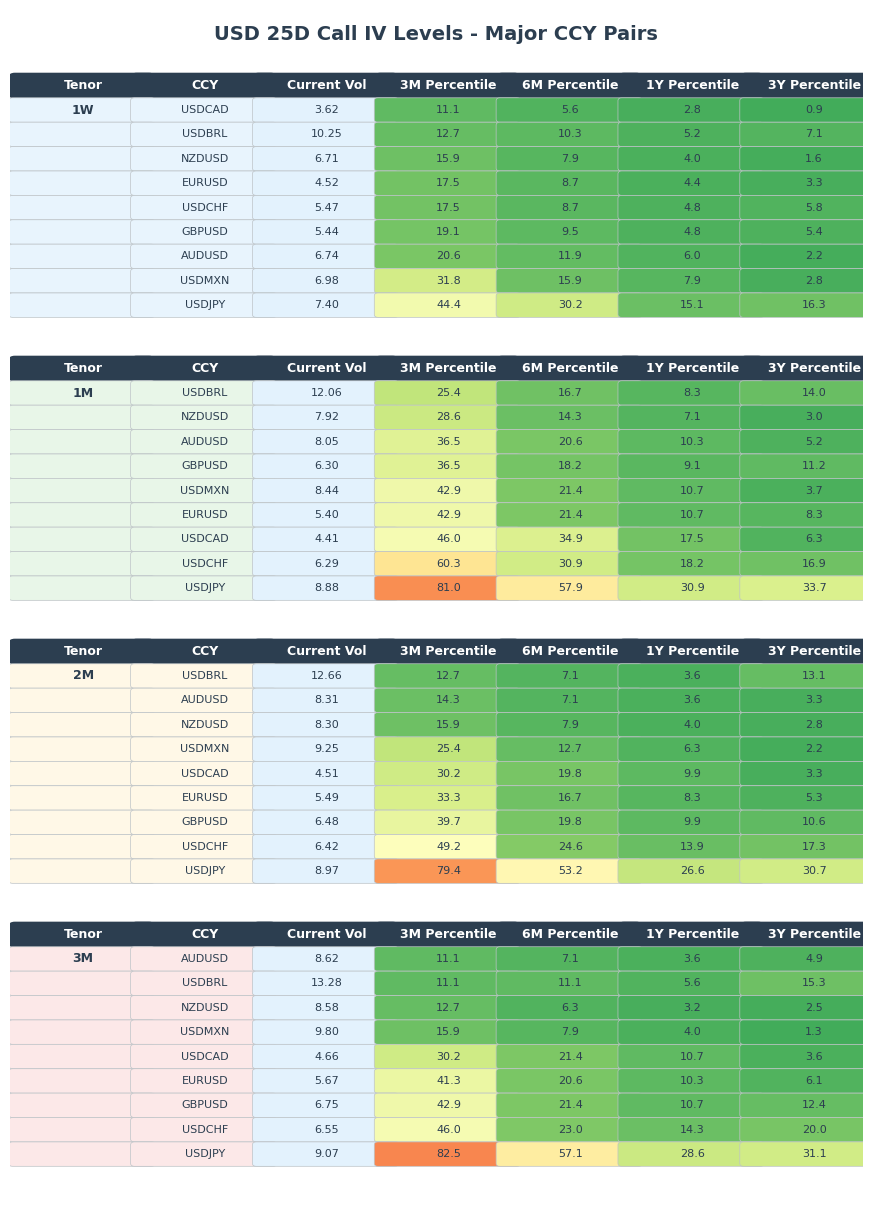

In [136]:
create_percentile_table_png(df_percentiles, df_current_vols)